\begin{align*}
J(\theta)=\frac{1}{2}\sum_{i=1}^{m}w^{(i)}(\theta^{T}x^{(i)}-y^{(i)})^{2}\\
\sum_{i=1}^{m}(\theta^{T}x^{(i)}-y^{(i)})^{2}=(X\theta-y)^{2}=(X\theta-y)^{T}(X\theta-y)
\end{align*}
$(X\theta-y)^{T}(X\theta-y)$ results in a scalar and $J(\theta)$ returns a scalar, so W has to be in the middle.\\ 
Now $(X\theta-y)^{T}$ shape is $(1,m)$ and $(X\theta-y)$ is $(m,1)$, so W has to be $(m,m)$ diagonal matrix with weights on the diagonal.
\begin{align*}
\nabla_\theta J(\theta)=\\
& =\nabla_\theta (X\theta-y)^{T}W(X\theta-y)\\
& =\nabla_\theta (X\theta)^{T}W(X\theta)-2y^{T}WX\theta+y^{T}Wy\\
& =2X^{T}WX\theta-2X^{T}Wy\\
\nabla_\theta J(\theta)=0\\
\theta=(X^{T}WX)^{-1}X^{T}Wy\\
\end{align*}

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('data/auto-mpg.csv')

In [3]:
df.isna().sum(axis=0)

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [4]:
df=pd.get_dummies(df,columns=['origin'],drop_first=True, dtype='int32')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   car name      398 non-null    str    
 8   origin_2      398 non-null    int32  
 9   origin_3      398 non-null    int32  
dtypes: float64(3), int32(2), int64(3), str(2)
memory usage: 28.1 KB


In [6]:
df.loc[~df['horsepower'].str.isdigit(),'horsepower']

32     ?
126    ?
330    ?
336    ?
354    ?
374    ?
Name: horsepower, dtype: str

In [7]:
df2=df.drop(df[~df['horsepower'].str.isdigit()].index)
df2['horsepower']=df2['horsepower'].astype('int64')

In [8]:
def plot_corr_matrix(data,cols=[]):
    num_cols=data.select_dtypes(exclude='object').columns
    if len(cols)!=0:
        num_cols=cols
    matrix = data[num_cols].corr()
    fig, ax = plt.subplots(figsize=(8,6))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    ax.set_title('Correlation Matrix')
    plt.show()

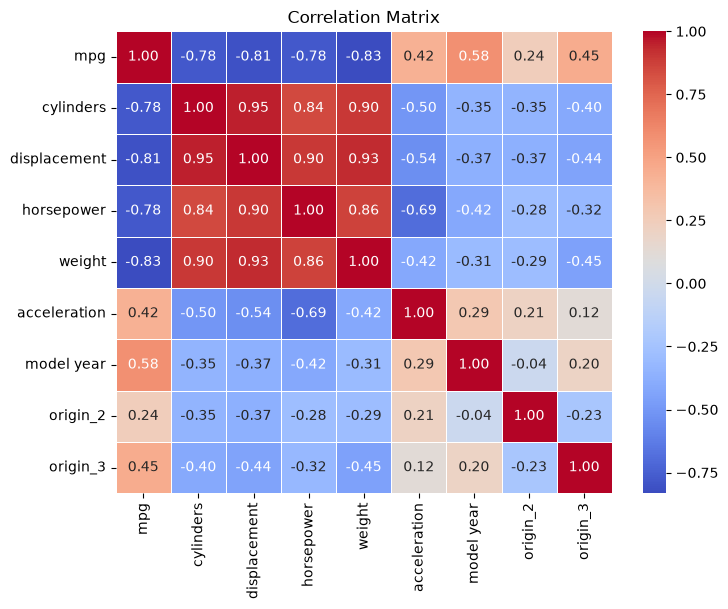

In [9]:
plot_corr_matrix(df2)

In [10]:
df2.drop(columns=['car name'],inplace=True)

In [11]:
X,y=df2.iloc[:,1:],df2.iloc[:,0]

In [12]:
X.insert(0,'x0',np.ones(X.shape[0]))

In [13]:
num_cols=X.loc[:,'cylinders':'model year'].columns

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test[num_cols]=scaler.transform(X_test[num_cols])

In [16]:
class Locally_weighted_LR:
    def __init__(self,tau=0.1):
        self.tau=tau
    def fit(self,X,y):
        self.X=np.asarray(X)
        self.y=np.asarray(y)
    def predict(self,X):
        m,n=self.X.shape
        X=np.asarray(X)
        l=X.shape[0]
        diff=np.reshape(X,(-1,l,n))-np.reshape(self.X,(m,-1,n))
        w=np.exp(-np.linalg.norm(diff,ord=2,axis=2)**2/(2*self.tau**2))#mxl
        W=np.apply_along_axis(np.diag,axis=0,arr=w).T #lxmxm
        XT_W=self.X.T@W
        theta = np.linalg.solve(XT_W @ self.X, np.reshape(XT_W @ self.y,(l,n,1))).squeeze()#lxn
        return np.sum(X*theta,axis=1)#lx1

In [17]:
df2['mpg'].describe()

count    392.000000
mean      23.445918
std        7.805007
min        9.000000
25%       17.000000
50%       22.750000
75%       29.000000
max       46.600000
Name: mpg, dtype: float64

In [18]:
lwr=Locally_weighted_LR(1.0)
lwr.fit(X_train.values,y_train.values)
preds_train=lwr.predict(X_train.values)
print(f"Average error for training set: {np.round(np.mean(np.abs(y_train.values-preds_train)),2)}")

Average error for training set: 1.49


In [19]:
lwr.fit(X_train.values,y_train.values)
preds=lwr.predict(X_test.values)
print(f"Average error for test set: {np.round(np.mean(np.abs(y_test.values-preds)),2)}")

Average error for test set: 1.81


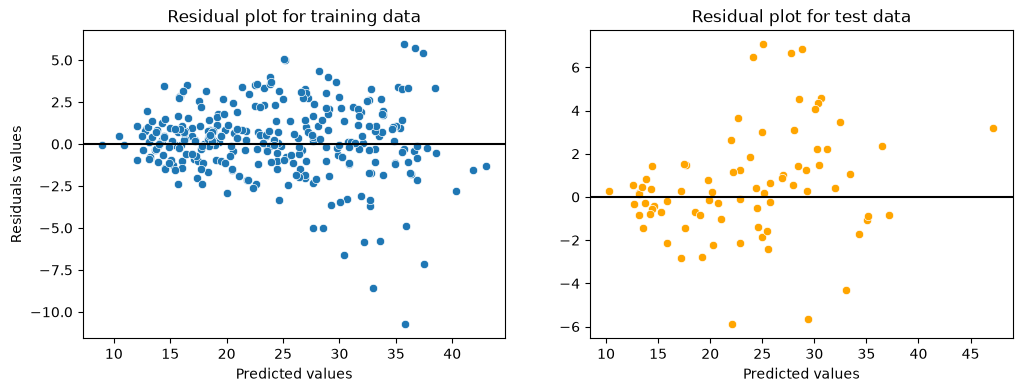

In [20]:
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))
#train
sns.scatterplot(x=preds_train,y=preds_train-y_train,ax=ax1)
ax1.set_title('Residual plot for training data')
ax1.set_ylabel('Residuals values')#errors
#test
sns.scatterplot(x=preds,y=preds-y_test,ax=ax2,c='orange')
ax2.set_title('Residual plot for test data')
ax2.set_ylabel('')
for ax in (ax1,ax2):
    ax.axhline(0,c='black')
    ax.set_xlabel('Predicted values')
plt.show()